<a href="https://colab.research.google.com/github/Hamzeh05/NLP-Project/blob/main/Phase%201(Data%20loading%20%26%20Data%20Preprocessing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading the datasets**

In [1]:


%%writefile downloader_extractor_utils.py
from collections import namedtuple
from datetime import datetime
import json
import re
from urllib.parse import urlparse

import bs4
from bs4 import BeautifulSoup
import dateutil.parser
import dateutil.tz
import regex

SiteConfig = namedtuple("SiteConfig",
                        ["encoding",
                         "body_extractor",
                         "title_extractor",
                         "pub_date_extractor"
                        ])

arabic_months = {
    'يناير': 1,
    'فبراير': 2,
    'مارس': 3,
    'أبريل': 4,
    'مايو': 5,
    'يونيو': 6,
    'يوليو': 7,
    'أغسطس': 8,
    'سبتمبر': 9,
    'أكتوبر': 10,
    'نوفمبر': 11,
    'ديسمبر': 12,
}

def parse_date(text):
    result = re.findall(r'\s(\d\d) \-(\d\d)\- (\d{4})', str(text))
    if result:
        year = int(result[0][2])
        month = int(result[0][1])
        day = int(result[0][0])
        return datetime(year, month, day)

    result = re.findall(r'\s(\d\d)/(\d\d)/(\d{4})', str(text))
    if result:
        year = int(result[0][2])
        month = int(result[0][1])
        day = int(result[0][0])
        return datetime(year, month, day)

    result = re.findall(r'(\d{2})\s(\w+)\s(\d{4})', str(text))
    if result:
        year = int(result[0][2])
        month_name = result[0][1]
        day = int(result[0][0])
        return datetime(year, arabic_months[month_name], day)

    print('error parsing date')
    return None

def get_first_line(text):
    return text.split('\n')[0]

def strip_colon_prefix(text):
    parts = text.split(':')
    prefix = parts[0].strip()
    if prefix in ('بالفيديو', 'بالصور'):
        return parts[1].strip()
    return text

def strip_dots_prefix(text):
    parts = text.split('..')
    prefix = parts[0].strip()
    if prefix in ('بالفيديو', 'بالصور', 'شاهد'):
        return parts[1].strip()
    return text

def _get_emaratalyoum_body(soup):
    for tag in soup.select('.metadata'):
        tag.extract()
    for tag in soup.select('script'):
        tag.extract()
    for tag in soup.select('.follow-google'):
        tag.extract()
    for tag in soup.select('.shareholder'):
        tag.extract()
    for tag in soup.select('#parsely-related-stories'):
        tag.extract()
    article = soup.select("#articledetails")
    if len(article) > 0:
        return article[0].get_text().strip()
    return ''

def emaratalyoum_body(soup):
    raw = _get_emaratalyoum_body(soup)
    return get_first_line(raw)

def emaratalyoum_title(soup):
    meta = soup.find("meta", {"property": "og:title"})
    if meta:
        title = strip_colon_prefix(meta['content'])
        title = strip_dots_prefix(title)
        return title
    return ''

def almamlakatv_body(soup):
    wrapper = soup.find('div', class_='article-body')
    if wrapper:
        paragraphs = wrapper.find_all('p')
        if paragraphs:
            return get_first_line(paragraphs[0].text.strip())
    return ''

def almamlakatv_title(soup):
    h1_tags = soup.find_all('h1')
    if len(h1_tags) > 0:
        return h1_tags[0].text.strip()
    return ''

def emaratalyoum_pubdate(soup):
    meta = soup.find("meta", {"property": "article:published_time"})
    if meta:
        return meta['content']
    return ''

def almamlakatv_pubdate(soup):
    time_tags = soup.find_all('time')
    if time_tags:
        parsed = parse_date(time_tags[0])
        if parsed:
            return str(parsed)
    return ''

site_configs = {
    'emaratalyoum.com': SiteConfig('utf-8',
                                   emaratalyoum_body,
                                   emaratalyoum_title,
                                   emaratalyoum_pubdate),
    'almamlakatv.com': SiteConfig('utf-8',
                                  almamlakatv_body,
                                  almamlakatv_title,
                                  almamlakatv_pubdate)
}

Writing downloader_extractor_utils.py


In [2]:
%%writefile downloader_extractor.py
import json
from urllib.parse import urlparse
from bs4 import BeautifulSoup
from downloader_extractor_utils import *

F_URL = 'url'
F_HEADLINE = 'headline'
F_TEXT = 'text'
F_SECTION = 'section'
F_SUBDOMAIN = 'subdomain'
F_FILENAME = 'filename'
F_OFFSET = 'offset'
F_LENGTH = 'length'
F_PUBLISHED = 'published'
F_DATASET = 'dataset'

class ArticleParser:
    @staticmethod
    def parse(raw_entry):
        return ArticleParser._build_record(raw_entry)

    @staticmethod
    def _build_record(entry):
        url = entry['url']
        parsed_url = urlparse(url)
        domain = '.'.join(parsed_url.netloc.rsplit('.', maxsplit=2)[-2:])
        subdomain = parsed_url.netloc.replace('www.', '')

        if domain == subdomain:
            section = (parsed_url.path.split('/') + [''])[1]
            if not section.isalnum():
                section = subdomain
        else:
            section = subdomain
            if 'blog' in section:
                section = 'blogs'

        config = site_configs.get(subdomain, site_configs.get(domain, None))

        raw_warc = entry['content']
        html = raw_warc.split('\r\n\r\n', maxsplit=2)[-1].replace('\r', '').replace('&nbsp;', ' ')
        soup = BeautifulSoup(html, 'html.parser')

        if config:
            title = config.title_extractor(soup)
            body = config.body_extractor(soup)
            pub_date = config.pub_date_extractor(soup)
        else:
            title = ""
            body = ""
            pub_date = ""

        return {
            F_URL: url,
            F_HEADLINE: title,
            F_TEXT: body,
            F_SECTION: section,
            F_SUBDOMAIN: subdomain,
            F_FILENAME: entry[F_FILENAME],
            F_OFFSET: entry[F_OFFSET],
            F_LENGTH: entry[F_LENGTH],
            F_PUBLISHED: pub_date,
            F_DATASET: entry[F_DATASET]
        }

Writing downloader_extractor.py


In [3]:
%%writefile main_downloader.py
import argparse
import gzip
import json
import lzma
import multiprocessing.pool
import sys
import urllib.request
from downloader_extractor import ArticleParser

SPLIT_NAMES = ["train", "valid", "test", "ood"]

parser = argparse.ArgumentParser()
parser.add_argument("--download_start", default=None, type=int)
parser.add_argument("--download_end", default=None, type=int)
parser.add_argument("--index_file", default="sumarabic-1.0-index.jsonl.xz", type=str)
parser.add_argument("--parallel", default=16, type=int)
parser.add_argument("--output_file", default="sumarabic-1.0-{}.jsonl", type=str)
args = parser.parse_args()

print("loading the index file.", file=sys.stderr)
index_data = []
try:
    with lzma.LZMAFile(args.index_file, "r") as idx_f:
        for row in idx_f:
            index_data.append(json.loads(row.decode("utf-8")))
except FileNotFoundError:
    print(f"error: {args.index_file} not found.", file=sys.stderr)
    sys.exit(1)

print("loading previously downloaded data.", file=sys.stderr)
split_files = {}
for split in SPLIT_NAMES:
    out_path = args.output_file.format(split)
    split_files[split] = {
        "file": open(out_path, "a+", encoding="utf-8"),
        "seen": set()
    }
    split_files[split]["file"].seek(0)
    for line_num, line in enumerate(split_files[split]["file"]):
        assert line.endswith("\n"), f"Last line of {out_path} is not properly ended"
        try:
            rec = json.loads(line)
            uid = str(rec["filename"]) + str(rec["offset"]) + str(rec["length"])
            split_files[split]["seen"].add(uid)
        except Exception:
            raise ValueError(f"cant decode line {line_num + 1} from {out_path}")

def fetch_and_parse(entry):
    split = entry["dataset"]
    uid = str(entry["filename"]) + str(entry["offset"]) + str(entry["length"])
    if uid in split_files[split]["seen"]:
        return None

    attempts = 0
    while True:
        try:
            url = "https://data.commoncrawl.org/{}".format(entry["filename"])
            byte_range = "bytes={}-{}".format(
                int(entry["offset"]),
                int(entry["offset"]) + int(entry["length"]) - 1
            )
            req = urllib.request.Request(url, headers={"Range": byte_range})
            with urllib.request.urlopen(req) as resp:
                with gzip.GzipFile(fileobj=resp) as gz:
                    entry["content"] = gz.read().decode("utf-8")
            break
        except Exception:
            attempts += 1
            if attempts >= 5:
                print(f"a lot of errors for entry {entry}, skipping.", file=sys.stderr)
                return None

    parsed = ArticleParser.parse(entry)
    del entry["content"]
    return parsed

print("downloading the data.", file=sys.stderr)
to_fetch = index_data[args.download_start:args.download_end]

pool = None
if args.parallel > 1:
    pool = multiprocessing.pool.Pool(args.parallel, initializer=lambda: sys.setrecursionlimit(1100))
    results = pool.imap(fetch_and_parse, to_fetch)
else:
    results = map(fetch_and_parse, to_fetch)

for i, record in enumerate(results):
    if record is not None:
        split_files[record["dataset"]]["file"].write(
            json.dumps(record, ensure_ascii=False, sort_keys=True, indent=None, separators=(", ", ": ")) + "\n"
        )
    if (i + 1) % 10 == 0:
        print(f"downloaded {i + 1}/{len(to_fetch)} documents.", end="\r", file=sys.stderr, flush=True)

if pool is not None:
    pool.close()
    pool.join()

print("all data downloaded successfully.", file=sys.stderr)

Writing main_downloader.py


In [4]:
!pip install beautifulsoup4 python-dateutil regex pandas
!python main_downloader.py --download_start 0 --download_end 100 --parallel 2

loading the index file.
loading previously downloaded data.
downloading the data.
all data downloaded successfully.


In [5]:
import pandas as pd
import json

jsonl_path = 'sumarabic-1.0-train.jsonl'
rows = []

try:
    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                rec = json.loads(line)
                if rec.get('text') and rec.get('headline'):
                    rows.append({
                        'document': rec['text'].strip(),
                        'summary': rec['headline'].strip(),
                        'source': rec['subdomain']
                    })
            except json.JSONDecodeError:
                continue

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df[(df['document'] != '') & (df['summary'] != '')]
        df.to_csv("arabic_summarization_dataset.csv", index=False, encoding='utf-8-sig')
        print(f"Saved {len(df)} rows to arabic_summarization_dataset.csv")
        display(df.head())
    else:
        print("no matching records found.")

except FileNotFoundError:
    print(f"file not found: {jsonl_path}.")

Saved 94 rows to arabic_summarization_dataset.csv


,document,summary,source
0,اختتمت مساء أول من أمس نهائيات بطولة الإمارات ...,المصري فؤاد الطاهر بطل للشطرنج الديناميكي,emaratalyoum.com
1,مينيابوليس (الولايات المتحدة) 3-2-2008 (ا ف ب)...,"حملة انتخابية محمومة قبل ""الثلاثاء الكبير""",emaratalyoum.com
2,أفاد مصدر في شرطة أبوظبي بأن نحو 700 طفل يتواف...,55% من نزلاء «الأحداث» مواطنون,emaratalyoum.com
3,قال استشاري أمراض الكلى في مدينة الشيخ خليفة ا...,مركز متخصص في الكلى بمستشفى خليفة,emaratalyoum.com
4,بدأت القيادة العامة لشرطة أبوظبي التنسيق لإنشا...,تأهيل ضحايا حوادث المرور في أبوظبي,emaratalyoum.com


In [6]:
import pandas as pd
import zipfile
import glob
import warnings
from datasets import load_dataset, utils

warnings.filterwarnings('ignore')

try:
    df_sumarabic = pd.read_csv("arabic_summarization_dataset.csv")
    df_sumarabic = df_sumarabic[['document', 'summary']]
    df_sumarabic['source_dataset'] = 'SumArabic'
except FileNotFoundError:
    df_sumarabic = pd.DataFrame(columns=['document', 'summary', 'source_dataset'])

try:
    with zipfile.ZipFile('AbsArSumCorpus_csv_v1.zip', 'r') as zf:
        zf.extractall('arasum_extracted')
    arasum_path = glob.glob('arasum_extracted/**/*.csv', recursive=True)[0]
    df_arasum = pd.read_csv(arasum_path, sep="\t", header=None, names=["document", "summary"]).dropna()
    df_arasum['source_dataset'] = 'AraSum'
except Exception:
    df_arasum = pd.DataFrame(columns=['document', 'summary', 'source_dataset'])

try:
    utils.logging.disable_progress_bar()
    hf_data = load_dataset("Omar-youssef/Egyptian-text-summarization", split="train", verification_mode="no_checks")
    df_egyptian = hf_data.to_pandas().rename(columns={'text': 'document', 'summarized_text': 'summary'})
    df_egyptian = df_egyptian[['document', 'summary']].dropna()
    df_egyptian['source_dataset'] = 'Egyptian'
except Exception:
    df_egyptian = pd.DataFrame(columns=['document', 'summary', 'source_dataset'])

try:
    with zipfile.ZipFile('summarizdataset.csv.zip', 'r') as zf:
        zf.extractall('kaggle_extracted')
    kaggle_path = glob.glob('kaggle_extracted/**/summarizdataset.csv', recursive=True)[0]
    df_kaggle = pd.read_csv(kaggle_path).rename(columns={'text': 'document', 'summarizer': 'summary'})
    df_kaggle = df_kaggle[['document', 'summary']].dropna()
    df_kaggle['source_dataset'] = 'Kaggle'
except Exception:
    df_kaggle = pd.DataFrame(columns=['document', 'summary', 'source_dataset'])

print("\nmerging datasets...")
master_df = pd.concat([df_sumarabic, df_arasum, df_egyptian, df_kaggle], ignore_index=True)

master_df['document'] = master_df['document'].astype(str)
master_df['summary'] = master_df['summary'].astype(str)
master_df = master_df.drop_duplicates(subset=['document'])
master_df = master_df[(master_df['document'] != 'nan') & (master_df['summary'] != 'nan')]

print("=" * 45)
print(f" UNIQUE DOCUMENTS: {len(master_df):,} ")
print("=" * 45)
print("\nbreakdown by Source:")
print(master_df['source_dataset'].value_counts().to_string())

print("\n\n--- sample record from each dataset ---")
samples = []
for src in master_df['source_dataset'].unique():
    samples.append(master_df[master_df['source_dataset'] == src].head(1))

if samples:
    display(pd.concat(samples))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.32M [00:00<?, ?B/s]


merging datasets...
 UNIQUE DOCUMENTS: 61,418 

breakdown by Source:
source_dataset
AraSum       49580
Kaggle        8055
Egyptian      3689
SumArabic       94


--- sample record from each dataset ---


,document,summary,source_dataset
0,اختتمت مساء أول من أمس نهائيات بطولة الإمارات ...,المصري فؤاد الطاهر بطل للشطرنج الديناميكي,SumArabic
94,"حقق حزب ""البديل من أجل ألمانيا"" اليميني الشعبو...",تشير آخر استطلاعات الرأي الألمانية إلى تقدم حز...,AraSum
49698,كتير من الشباب دلوقتي بيفكروا ألف مرة قبل ما ي...,غلاء المعيشة بيخلي الشباب يقللوا عدد الأطفال ب...,Egyptian
53387,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,Kaggle


# **Explaratory Data Analysis**

In [7]:
master_df.columns

Index(['document', 'summary', 'source_dataset'], dtype='object')

--- sequence length statistics ---


,doc_len,sum_len,compression_ratio
count,61418.000000,61418.000000,61418.000000
mean,321.507408,33.665896,0.185865
std,232.114182,9.303317,0.185173
min,12.000000,2.000000,0.006173
25%,158.000000,30.000000,0.078788
50%,269.000000,34.000000,0.122951
75%,425.000000,36.000000,0.205556
max,2898.000000,88.000000,1.057143


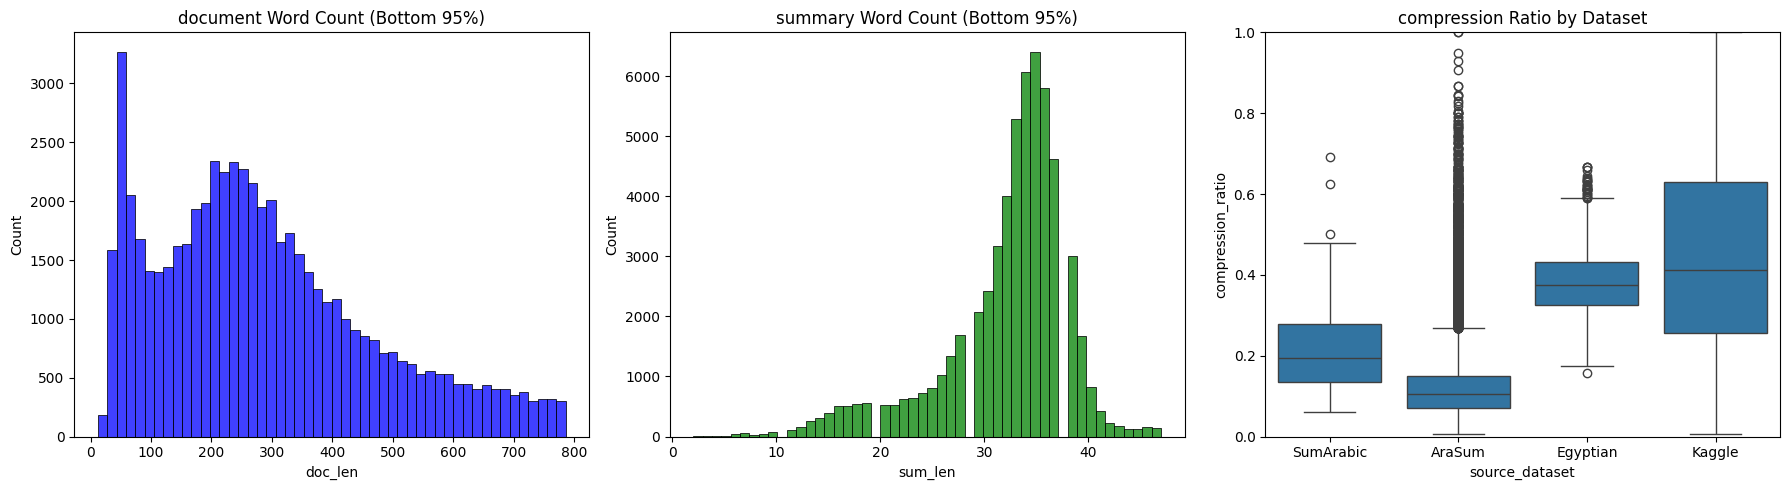

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

master_df['doc_len'] = master_df['document'].apply(lambda x: len(str(x).split()))
master_df['sum_len'] = master_df['summary'].apply(lambda x: len(str(x).split()))
master_df['compression_ratio'] = master_df['sum_len'] / master_df['doc_len']

master_df.replace([np.inf, -np.inf], np.nan, inplace=True)
master_df.dropna(subset=['compression_ratio'], inplace=True)

print("--- sequence length statistics ---")
display(master_df[['doc_len', 'sum_len', 'compression_ratio']].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

doc_cap = master_df['doc_len'].quantile(0.95)
sns.histplot(master_df[master_df['doc_len'] < doc_cap]['doc_len'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('document Word Count (Bottom 95%)')

sum_cap = master_df['sum_len'].quantile(0.95)
sns.histplot(master_df[master_df['sum_len'] < sum_cap]['sum_len'], bins=50, ax=axes[1], color='green')
axes[1].set_title('summary Word Count (Bottom 95%)')

sns.boxplot(x='source_dataset', y='compression_ratio', data=master_df, ax=axes[2])
axes[2].set_title('compression Ratio by Dataset')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# **Our EDA Findings:**

---



Document Lengths: 75% of our documents are under 425 words. We will set the encoder's MAX_TEXT_LEN to 400 to optimize memory.

Summary Lengths: Our target summaries are very consistent (mostly 30-36 words). We will set the decoder's MAX_SUMMARY_LEN to 50.

Dataset Variance: The AraSum dataset is highly compressive (summaries are ~10% of the text length), while the Egyptian and Kaggle datasets are much less compressed (~40%).

Anomalies: We discovered invalid rows where summaries are actually longer than the original text (ratio > 1.0). We will filter these out before training.


# **Data Preprocessing**

In [9]:
import re
import pandas as pd
import numpy as np

master_df['doc_len'] = master_df['document'].apply(lambda x: len(str(x).split()))
master_df['sum_len'] = master_df['summary'].apply(lambda x: len(str(x).split()))
master_df['ratio'] = master_df['sum_len'] / master_df['doc_len']
master_df = master_df[(master_df['ratio'] < 1.0) & (master_df['ratio'] > 0.05)].copy()

def clean_arabic(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|[a-zA-Z]', '', text)
    text = re.sub(r'[\u064B-\u065F\u0640]', '', text)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub(r'\bال', '', text)
    text = re.sub(r'\bوبال', '', text)
    text = re.sub(r'([^\w\s\ا-ي0-9\.،؟])', r' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

master_df['clean_doc'] = master_df['document'].apply(clean_arabic)
master_df['clean_summary'] = master_df['summary'].apply(lambda x: f"sostok {clean_arabic(x)} eostok")

clean_df = master_df[
    (master_df['clean_doc'].str.split().str.len().between(1, 400)) &
    (master_df['clean_summary'].str.split().str.len().between(3, 50))
][['clean_doc', 'clean_summary']].copy()

print(f"clean samples: {len(clean_df)}")

clean samples: 40338


In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_ENC_LEN = 400
MAX_DEC_LEN = 50
VOCAB_SIZE = 40000

docs = list(clean_df['clean_doc'])
summaries = list(clean_df['clean_summary'])

docs_train, docs_temp, sums_train, sums_temp = train_test_split(
    docs, summaries, test_size=0.2, random_state=42
)
docs_val, docs_test, sums_val, sums_test = train_test_split(
    docs_temp, sums_temp, test_size=0.5, random_state=42
)

enc_tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<UNK>')
enc_tok.fit_on_texts(docs_train)

dec_tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<UNK>')
dec_tok.fit_on_texts(sums_train)

assert 'sostok' in dec_tok.word_index, "sostok missing from decoder vocab!"
assert 'eostok' in dec_tok.word_index, "eostok missing from decoder vocab!"

enc_train = pad_sequences(enc_tok.texts_to_sequences(docs_train), maxlen=MAX_ENC_LEN, padding='post')
enc_val   = pad_sequences(enc_tok.texts_to_sequences(docs_val),   maxlen=MAX_ENC_LEN, padding='post')
enc_test  = pad_sequences(enc_tok.texts_to_sequences(docs_test),  maxlen=MAX_ENC_LEN, padding='post')

dec_train = pad_sequences(dec_tok.texts_to_sequences(sums_train), maxlen=MAX_DEC_LEN, padding='post')
dec_val   = pad_sequences(dec_tok.texts_to_sequences(sums_val),   maxlen=MAX_DEC_LEN, padding='post')
dec_test  = pad_sequences(dec_tok.texts_to_sequences(sums_test),  maxlen=MAX_DEC_LEN, padding='post')

print(f"train  — encoder: {enc_train.shape}, decoder: {dec_train.shape}")
print(f"val    — encoder: {enc_val.shape},   decoder: {dec_val.shape}")
print(f"test   — encoder: {enc_test.shape},  decoder: {dec_test.shape}")
print(f"\nencoder vocab size: {len(enc_tok.word_index)}")
print(f"decoder vocab size: {len(dec_tok.word_index)}")

train  — encoder: (32270, 400), decoder: (32270, 50)
val    — encoder: (4034, 400),   decoder: (4034, 50)
test   — encoder: (4034, 400),  decoder: (4034, 50)

encoder vocab size: 214677
decoder vocab size: 77511
